# Cuestionario 2 — MATI

**Matemática Aplicada a las Tecnologías de la Información** · Grado en Ingeniería Informática · Universidad de Sevilla · Curso 2026/2027

**Opción B:** generalización mediante grafos del problema de los misioneros y los caníbales, y del problema del hombre, el lobo, la gallina y la lechuga.

> ⚙️ **Kernel:** este notebook usa el kernel `Python (MATI .venv)`. Si al ejecutar aparece `ModuleNotFoundError`, ve a **Kernel → Change Kernel** y selecciónalo (ver `GUIA_USO.md` §1.2).

In [1]:
# Librerías que se usan en todo el notebook + funciones de dibujo compartidas
import networkx as nx            # crear y analizar grafos
import matplotlib.pyplot as plt  # dibujar (uso directo solo si mati_utils no basta)
from itertools import product    # combinaciones de carga del barco
from collections import deque    # cola para el recorrido en anchura (BFS)

from mati_utils import dibujar_grafo, dibujar_multigrafo, SEED  # funciones de dibujo, comentadas en notebooks/mati_utils.py

---

## Actividad — Opción B

<div style="border-left:5px solid #888;background:#F2F2F2;padding:10px 14px;margin:10px 0;border-radius:4px;"><p><strong>📋 ENUNCIADO</strong></p><p><em>La actividad ofrecía dos opciones y se resuelve una: <strong>opción B</strong>.</em></p><p>Generaliza el problema de los caníbales y los misioneros usando grafos. ¡Qué ocurre con 4 caníbales, 4 misioneros y un bote de 2 personas?.</p><p>Ya puestos, estudia el problema del hombre, el lobo, la gallina y la lechuga. Generaliza (n hombres-canoas, l lobos, g gallinas, k lechugas...)</p></div>

<div style="border-left:5px solid #4C72B0;background:#EEF2FA;padding:10px 14px;margin:10px 0;border-radius:4px;"><p><strong>📚 TEORÍA</strong></p><p><strong>La idea clave: convertir un acertijo en un grafo.</strong> En vez de buscar la solución a mano probando viajes, se construye un grafo donde cada <strong>vértice es una situación completa del problema</strong> (un <em>estado</em>) y cada <strong>arista es un viaje permitido</strong> que lleva de una situación a otra. Resolver el acertijo pasa entonces a ser una pregunta de grafos: ¿hay forma de llegar del vértice inicial al vértice final?</p><p><strong>Vocabulario mínimo</strong> (todo en lenguaje llano antes que en notación):</p><ul><li><strong>Estado:</strong> una foto completa de la situación. Aquí basta con anotar qué hay en la orilla izquierda y dónde está el bote, porque lo que no está a la izquierda está a la derecha. Para los misioneros y caníbales, un estado es la terna $(m, c, b)$: $m$ misioneros y $c$ caníbales en la orilla izquierda, y $b$ el lado en el que está el bote.</li><li><strong>Estado válido:</strong> el que no viola las reglas. En misioneros y caníbales: en ninguna de las dos orillas puede haber misioneros <em>superados en número</em> por caníbales (si hay 0 misioneros en una orilla, no pasa nada, no hay a quién superar).</li><li><strong>Camino:</strong> una sucesión de vértices en la que cada uno está unido al siguiente por una arista. Aquí, una secuencia de viajes válidos.</li><li><strong>Componente conexa:</strong> un trozo del grafo en el que todos sus vértices están comunicados entre sí por caminos, y que no tiene ninguna arista hacia el resto del grafo. Es la noción que da la respuesta al caso imposible: si el estado final está en una componente <em>distinta</em> a la del inicial, <strong>no hay ninguna secuencia de viajes que lleve de uno a otro</strong> — y eso es una demostración, no una sospecha.</li><li><strong>Recorrido en anchura (BFS):</strong> la forma estándar de explorar un grafo por capas desde un vértice. Encuentra el camino con <em>menos aristas</em>, que aquí significa la solución con el <strong>menor número de viajes</strong>. En NetworkX lo dan <code>nx.shortest_path</code> y <code>nx.has_path</code>.</li></ul><p><strong>Por qué el grafo es no dirigido.</strong> Todo viaje se puede deshacer navegando de vuelta, así que si un estado lleva a otro, también se puede volver: las aristas no tienen sentido único y basta <code>nx.Graph</code>.</p><p><strong>Ejemplo pequeño para fijar la idea</strong> (1 misionero, 1 caníbal, bote de 2): los estados válidos son pocos, y desde $(1,1,\text{izq})$ se cruza a los dos de una vez hasta $(0,0,\text{der})$. Un solo viaje, un camino de una sola arista.</p><p><strong>El segundo problema es el mismo esquema.</strong> En el del hombre, el lobo, la gallina y la lechuga el estado es <em>qué subconjunto de los tres objetos está en la orilla izquierda</em>, más el lado en el que está el hombre. Un estado es válido si, en la orilla sin el hombre, no quedan juntos lobo y gallina ni gallina y lechuga. Con 3 objetos salen $2^3 \cdot 2 = 16$ estados: el grafo entero cabe en un dibujo.</p></div>

<div style="border-left:5px solid #8172B2;background:#F1EEF9;padding:10px 14px;margin:10px 0;border-radius:4px;"><p><strong>🔢 DATOS</strong></p><p><strong>Problema 1 — misioneros y caníbales.</strong></p><ul><li><strong>Caso clásico (referencia):</strong> $3$ misioneros, $3$ caníbales, bote de $2$ plazas. Se sabe que tiene solución; sirve para comprobar que el modelo está bien construido antes de atacar el caso del enunciado.</li><li><strong>Caso del enunciado:</strong> $4$ misioneros, $4$ caníbales, bote de $2$ plazas.</li><li><strong>Reglas:</strong> el bote lleva entre $1$ y $c$ personas (nunca cruza vacío) y en cada orilla los misioneros no pueden ser superados en número por los caníbales.</li><li><strong>Estado inicial:</strong> todos en la izquierda, $(4, 4, 0)$. &nbsp; <strong>Estado final:</strong> todos en la derecha, $(0, 0, 1)$.</li></ul><p><strong>Problema 2 — el hombre, el lobo, la gallina y la lechuga.</strong></p><ul><li><strong>Objetos:</strong> lobo, gallina y lechuga. <strong>Incompatibilidades</strong> (parejas que no pueden quedarse solas sin el hombre): lobo–gallina y gallina–lechuga; lobo–lechuga no tiene conflicto.</li><li><strong>Capacidad de la canoa:</strong> $c = 2$, contando <em>al hombre dentro</em> de la capacidad — así el caso clásico (el hombre solo, o el hombre con un animal) sale como caso particular del modelo general.</li><li><strong>Estado inicial:</strong> los tres objetos y el hombre en la izquierda. &nbsp; <strong>Estado final:</strong> los tres en la derecha.</li><li><strong>Generalización pedida:</strong> $n$ hombres-canoas, $l$ lobos, $g$ gallinas, $k$ lechugas.</li></ul></div>

In [2]:
# ============================================================
#  DATOS — problema 1: misioneros y caníbales
# ============================================================
MISIONEROS = 4          # misioneros del caso del enunciado
CANIBALES = 4           # caníbales del caso del enunciado
CAPACIDAD_BOTE = 2      # plazas del bote (mínimo 1 persona por viaje: nunca cruza vacío)

# Caso clásico, para contrastar que el modelo funciona antes de ir al del enunciado
CASO_CLASICO = (3, 3, 2)   # (misioneros, caníbales, capacidad)

# ============================================================
#  DATOS — problema 2: hombre, lobo, gallina y lechuga
# ============================================================
OBJETOS = ("lobo", "gallina", "lechuga")

# Parejas que no pueden quedarse solas en una orilla sin el hombre
INCOMPATIBLES = [("lobo", "gallina"), ("gallina", "lechuga")]

CAPACIDAD_CANOA = 2     # el hombre cuenta dentro de la capacidad: él + un objeto

print(f"Misioneros y caníbales : {MISIONEROS} + {CANIBALES}, bote de {CAPACIDAD_BOTE}")
print(f"Caso clásico de control: {CASO_CLASICO[0]} + {CASO_CLASICO[1]}, bote de {CASO_CLASICO[2]}")
print(f"Objetos                : {OBJETOS}, canoa de {CAPACIDAD_CANOA} (hombre incluido)")
print(f"Incompatibilidades     : {INCOMPATIBLES}")

Misioneros y caníbales : 4 + 4, bote de 2
Caso clásico de control: 3 + 3, bote de 2
Objetos                : ('lobo', 'gallina', 'lechuga'), canoa de 2 (hombre incluido)
Incompatibilidades     : [('lobo', 'gallina'), ('gallina', 'lechuga')]


---

### Parte 1 — Misioneros y caníbales

<div style="border-left:5px solid #55A868;background:#EAF6ED;padding:10px 14px;margin:10px 0;border-radius:4px;"><p><strong>🧮 RESOLUCIÓN — Parte 1: misioneros y caníbales</strong></p><p><strong>✍️ Trabajo del estudiante</strong></p><p><strong>Modelización mediante un grafo $G$</strong> para el problema generalizado: $m$ misioneros, $n$ caníbales, barco de capacidad $c$.</p><p><strong>Restricciones de partida.</strong></p><ul><li>$n \le m$ — si hay más caníbales que misioneros en la orilla inicial el problema no tiene solución; si $m = 0$ es trivial. No hace falta imponer $m = n$.</li><li>$c \ge 2$ — con capacidad $1$ el barco nunca puede volver solo, y el problema no tiene solución.</li></ul><p><strong>Vértices.</strong> Orillas $A$ (origen) y $B$ (destino). Cada nodo se etiqueta $(x, y, b)$ con $x$ misioneros en $A$, $y$ caníbales en $A$, y $b \in \{0,1\}$ según el barco esté en $A$ ($0$) o en $B$ ($1$). Las dos cantidades se miden en la <em>misma</em> orilla; lo que hay en $B$ sale como $m-x$ y $n-y$. Nodo inicial $(m, n, 0)$, nodo objetivo $(0, 0, 1)$.</p><p><strong>Condición de validez de un nodo</strong> (nadie es devorado en ninguna orilla):</p>$$(x = 0 \;\lor\; x \ge y) \;\land\; (m - x = 0 \;\lor\; m - x \ge n - y).$$<p>Las disyunciones son necesarias: sin misioneros en una orilla no hay riesgo, sea cual sea el número de caníbales (por ejemplo $x = 0$, $y = 3$ es un estado perfectamente válido).</p><p><strong>Número de nodos.</strong> El espacio total de etiquetas es $(m+1)(n+1)\cdot 2$, del que solo un subconjunto cumple la condición anterior.</p><p><strong>Aristas.</strong> Desde $(x, y, 0)$ hay arista hacia $(x-i,\, y-j,\, 1)$ para todo $i, j \ge 0$ con</p>$$1 \le i + j \le c, \qquad i \le x, \qquad j \le y,$$<p>y análogamente desde $(x, y, 1)$ hacia $(x+i,\, y+j,\, 0)$. El barco cambia de orilla en cada movimiento, $b' = 1 - b$. Cada arista solo es válida si <em>tanto el nodo origen como el destino</em> cumplen la condición de validez. Con esta formulación general, el caso $c = 2$ (los cinco movimientos clásicos) sale como caso particular, sin enumerarlos a mano.</p><p><strong>Búsqueda.</strong> Sobre este grafo se puede buscar cualquier camino entre $(m,n,0)$ y $(0,0,1)$ por anchura (BFS), por profundidad, o con una búsqueda guiada por la heurística</p>$$h(x, y) = \left\lceil \frac{x+y}{c} \right\rceil,$$<p>el número mínimo de viajes necesarios para trasladar a las $x+y$ personas que quedan en $A$, dado que cada viaje lleva como mucho $c$ personas. Es una estimación más ajustada del coste restante que $h = x + y$.</p><p><strong>Hipótesis para $m = n = 4$.</strong> El caso clásico ($m = n = 3$, $c = 2$) se resuelve en $11$ movimientos. La hipótesis es que <strong>con $c = 2$ el problema deja de tener solución para $m = n = 4$</strong> — el cuello de botella del barco de dos plazas ya no permite mantener segura la orilla de partida mientras se traslada gente — y que a partir de $c = 3$ vuelve a ser resoluble.</p><p><strong>Resultado</strong> (construyendo el grafo y preguntando por la existencia de camino):</p><ul><li>$c = 2$: <strong>sin solución</strong></li><li>$c = 3$: soluble en $9$ movimientos</li><li>$c = 4$: soluble en $5$ movimientos</li><li>$c = 5$: soluble en $3$ movimientos</li></ul><p>Esto confirma la hipótesis: para $m = n = 4$ el problema es irresoluble justo con la capacidad clásica $c = 2$, y basta subir el barco una plaza para que vuelva a tener solución. La intuición: con $c = 2$ cada viaje de ida mueve como mucho dos personas y cada viaje de vuelta tiene que devolver al menos una, así que el ritmo neto de traslado es demasiado lento para mantener $x \ge y$ en ambas orillas cuando hay cuatro y cuatro; con $c = 3$ ya se pueden mover tres de golpe y el margen de seguridad no se rompe.</p></div>

**💻 CÓDIGO — Parte 1**

**✍️ Trabajo del estudiante**

Caso clásico 3+3, c=2: 20 nodos, 34 aristas
  soluble en 11 movimientos
----------------------------------------------------------------------
c=2: SIN SOLUCIÓN
c=3: SOLUBLE, 9 movimientos
      (4, 4, 0) -> (4, 2, 1) -> (4, 3, 0) -> (4, 0, 1) -> (4, 1, 0) -> (1, 1, 1) -> (2, 2, 0) -> (0, 2, 1) -> (0, 3, 0) -> (0, 0, 1)
c=4: SOLUBLE, 5 movimientos
      (4, 4, 0) -> (4, 2, 1) -> (4, 3, 0) -> (0, 3, 1) -> (0, 4, 0) -> (0, 0, 1)
c=5: SOLUBLE, 3 movimientos
      (4, 4, 0) -> (4, 0, 1) -> (4, 1, 0) -> (0, 0, 1)
----------------------------------------------------------------------


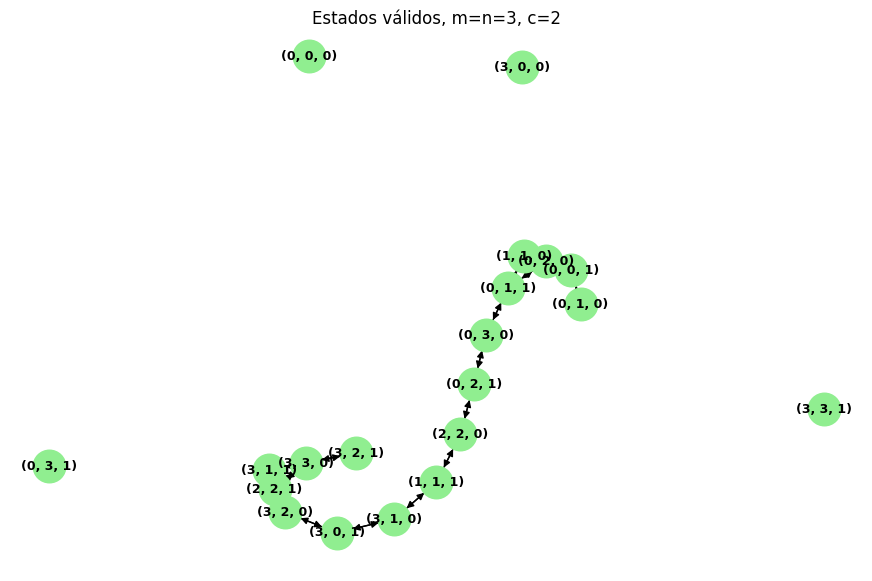

In [3]:
# ============================================================
#  PARTE 1 — misioneros y caníbales: grafo de estados
# ============================================================

def grafo_misioneros(m, n, c):
    """Grafo de estados válidos del problema generalizado.

    m misioneros, n caníbales y un barco de capacidad c.
    Nodo (x, y, b): x misioneros e y caníbales en la orilla A; b = 0 barco en A, b = 1 en B.
    """
    # Una orilla es segura si no tiene misioneros o si estos no están en inferioridad.
    # Se exige en las dos a la vez: A = (x, y) y B = (m - x, n - y).
    def seguro(x, y):
        return (x == 0 or x >= y) and (m - x == 0 or m - x >= n - y)

    G = nx.DiGraph()

    # Vértices: todos los repartos seguros, con el barco en cada una de las dos orillas
    for x in range(m + 1):
        for y in range(n + 1):
            if seguro(x, y):
                G.add_node((x, y, 0))
                G.add_node((x, y, 1))

    # Aristas: un viaje sube i misioneros y j caníbales al barco (entre 1 y c personas).
    # El signo depende de la orilla en la que esté el barco, y el destino solo se acepta
    # si es un nodo válido — es decir, si ya está en el grafo.
    for (x, y, b) in list(G.nodes):
        disponibles = (x, y) if b == 0 else (m - x, n - y)
        for i in range(0, c + 1):
            for j in range(0, c + 1 - i):
                if i + j < 1 or i > disponibles[0] or j > disponibles[1]:
                    continue
                signo = -1 if b == 0 else 1
                destino = (x + signo * i, y + signo * j, 1 - b)
                if destino in G.nodes:
                    G.add_edge((x, y, b), destino)
    return G


# --- 1. Caso clásico de control: 3 + 3 con bote de 2 debe ser soluble ---
m0, n0, c0 = CASO_CLASICO
G3 = grafo_misioneros(m0, n0, c0)
camino_clasico = nx.shortest_path(G3, (m0, n0, 0), (0, 0, 1))

print(f"Caso clásico {m0}+{n0}, c={c0}: {G3.number_of_nodes()} nodos, {G3.number_of_edges()} aristas")
print(f"  soluble en {len(camino_clasico) - 1} movimientos")
print("-" * 70)

# --- 2. Caso del enunciado: 4 + 4, subiendo la capacidad del barco ---
inicio, meta = (MISIONEROS, CANIBALES, 0), (0, 0, 1)
for c in range(2, 6):
    G = grafo_misioneros(MISIONEROS, CANIBALES, c)
    if nx.has_path(G, inicio, meta):
        camino = nx.shortest_path(G, inicio, meta)
        print(f"c={c}: SOLUBLE, {len(camino) - 1} movimientos")
        print(f"      {' -> '.join(str(e) for e in camino)}")
    else:
        print(f"c={c}: SIN SOLUCIÓN")
print("-" * 70)

# --- 3. El grafo del caso clásico es pequeño: se puede dibujar entero ---
fig, ax = plt.subplots(figsize=(11, 7))
dibujar_grafo(G3, titulo=f"Estados válidos, m=n={m0}, c={c0}", color_nodos="lightgreen", ax=ax)
plt.show()

---

### Parte 2 — El hombre, el lobo, la gallina y la lechuga

<div style="border-left:5px solid #55A868;background:#EAF6ED;padding:10px 14px;margin:10px 0;border-radius:4px;"><p><strong>🧮 RESOLUCIÓN — Parte 2: hombre, lobo, gallina y lechuga</strong></p><p><strong>✍️ Trabajo del estudiante</strong></p><p><strong>Estructura del problema clásico.</strong> A diferencia de misioneros y caníbales, donde la relación es simétrica (cualquier caníbal amenaza a cualquier misionero), aquí las incompatibilidades forman una <strong>cadena de depredación</strong>:</p><ul><li>lobo ↔ gallina: conflicto (el lobo se come a la gallina)</li><li>gallina ↔ lechuga: conflicto (la gallina se come la lechuga)</li><li>lobo ↔ lechuga: <strong>sin conflicto</strong></li></ul><p>Y solo el hombre puede remar: los animales no viajan solos ni pilotan la canoa.</p><p><strong>Generalización:</strong> $n$ hombres, $l$ lobos, $g$ gallinas, $k$ lechugas y capacidad $c$.</p><p><strong>Vértices.</strong> $(a, w, s, z, b)$, referidos a la orilla $A$: $a$ hombres, $w$ lobos, $s$ gallinas y $z$ lechugas (uso $s$ para las gallinas y no $g$, para no chocar con la $g$ global del enunciado), y $b$ la orilla del barco. Nodo inicial $(n, l, g, k, 0)$, nodo objetivo $(0,0,0,0,1)$.</p><p><strong>Condición de validez de un nodo.</strong> El conflicto solo importa cuando no hay ningún hombre vigilando esa orilla:</p>$$\mathrm{seguro}(a, w, s, z) \;\equiv\; a > 0 \;\lor\; \big(\lnot(w>0 \land s>0) \;\land\; \lnot(s>0 \land z>0)\big).$$<p>Es decir: si no hay hombres, no puede haber a la vez lobos y gallinas, ni a la vez gallinas y lechugas (lobo + lechuga sin gallina siempre es seguro). Un nodo es válido si $\mathrm{seguro}(a,w,s,z)$ se cumple en $A$ <strong>y</strong> $\mathrm{seguro}(n-a,\, l-w,\, g-s,\, k-z)$ se cumple en $B$. Nótese que <strong>la gallina es el elemento crítico</strong>: solo genera peligro si nadie vigila y hay al menos otro elemento de la cadena junto a ella.</p><p><strong>Número de nodos.</strong> Espacio de etiquetas $(n+1)(l+1)(g+1)(k+1)\cdot 2$, del que solo es válido el subconjunto que cumple lo anterior.</p><p><strong>Aristas.</strong> Desde $(a,w,s,z,0)$ hay arista hacia $(a-i,\, w-p,\, s-q,\, z-r,\, 1)$ si</p>$$1 \le i+p+q+r \le c, \qquad i \ge 1, \qquad i \le a,\; p \le w,\; q \le s,\; r \le z,$$<p>y simétricamente en sentido inverso. La condición $i \ge 1$ es <strong>la diferencia estructural clave</strong> frente a misioneros y caníbales: allí el barco podía llevar solo caníbales o solo misioneros; aquí nunca puede moverse sin al menos un hombre a bordo, así que no existe la arista «vacía de hombres».</p><p><strong>Caso clásico</strong> ($n = l = g = k = 1$, $c = 2$ contando al hombre dentro de la capacidad): las únicas aristas útiles con $i = 1$ son $(1,0,0,0)$, $(1,1,0,0)$, $(1,0,1,0)$ y $(1,0,0,1)$ — el hombre solo o con un animal —, que es exactamente el conjunto de movimientos del enunciado original. La solución son $7$ viajes, los de siempre.</p><p><strong>Heurística para búsqueda informada:</strong> $h = \left\lceil (w+s+z)/(c-1) \right\rceil$ si se exige que un hombre ocupe siempre un hueco de la capacidad, ya que cada viaje útil traslada como mucho $c-1$ animales.</p><hr><p><strong>Variante: $n$ canoas independientes (una por hombre).</strong></p><p>Si cada hombre lleva <em>siempre su canoa consigo</em>, deja de existir «el barco» como recurso único cuya posición haya que rastrear: cualquier hombre puede remar desde la orilla en la que esté. Eso <strong>elimina la componente $b$</strong>, el estado se reduce a $(a,w,s,z)$ y el espacio de etiquetas pasa a ser $(n+1)(l+1)(g+1)(k+1)$, sin el factor $2$ — esa es la primera consecuencia estructural.</p><p>La condición de validez no cambia (el conflicto no depende de cuántas canoas haya, solo de si hay algún hombre presente). Las aristas sí: una acción elige una dirección y un grupo de $i$ hombres que cruzan <em>simultáneamente, cada uno en su canoa</em>, llevando entre todos $p$ lobos, $q$ gallinas y $r$ lechugas. Desde $(a,w,s,z)$ hay arista hacia $(a-i,\,w-p,\,s-q,\,z-r)$ si</p>$$1 \le i \le a, \qquad p \le w,\; q \le s,\; r \le z, \qquad p+q+r \le i\cdot c,$$<p>y simétricamente en sentido contrario. La diferencia esencial frente a la canoa compartida: allí cada arista movía como mucho $c$ unidades y el barco tenía que volver en una arista aparte; aquí <strong>en una sola arista pueden cruzar varios hombres a la vez</strong>, la capacidad efectiva de una acción es $i \cdot c$, y no hace falta ninguna arista de «retorno del barco vacío».</p><p><strong>Consecuencia práctica.</strong> Con $i = a$ se puede vaciar de golpe hasta $a\cdot c$ animales de una orilla en una sola arista, lo que en muchos casos resuelve el problema en <strong>una única transición</strong>, porque no hay restricción de conflicto durante la travesía: solo importa el estado en cada orilla antes y después. El problema deja de ser un rompecabezas de vaivenes y pasa a ser un problema de factibilidad de reparto. Para conservar la dificultad combinatoria del puzzle clásico habría que limitar $i = 1$ (un solo hombre cruza por acción, aunque disponga de canoa propia): en ese caso el grafo es idéntico en forma al de una sola canoa compartida, salvo que desaparece $b$ y las condiciones $i \le a$ / $i \le n-a$ sustituyen al antiguo bit de posición del barco.</p></div>

**💻 CÓDIGO — Parte 2**

**✍️ Trabajo del estudiante**

Grafo: 20 nodos válidos, 20 aristas
Solución en 7 viajes:
  0. (1, 1, 1, 1, 0)  orilla A: hombre, lobo, gallina, lechuga
  1. (0, 1, 0, 1, 1)  orilla A: lobo, lechuga
  2. (1, 1, 0, 1, 0)  orilla A: hombre, lobo, lechuga
  3. (0, 1, 0, 0, 1)  orilla A: lobo
  4. (1, 1, 1, 0, 0)  orilla A: hombre, lobo, gallina
  5. (0, 0, 1, 0, 1)  orilla A: gallina
  6. (1, 0, 1, 0, 0)  orilla A: hombre, gallina
  7. (0, 0, 0, 0, 1)  orilla A: (vacía)
----------------------------------------------------------------------


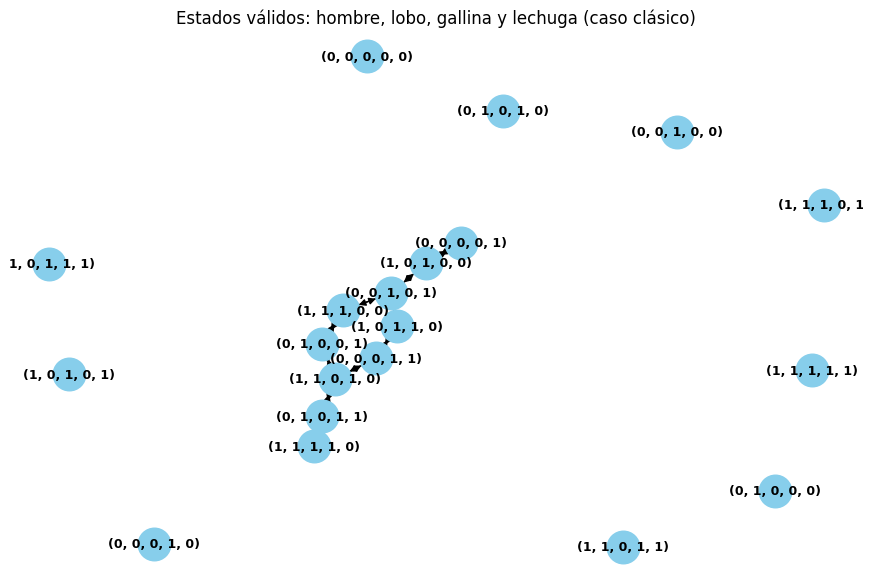

In [4]:
# ============================================================
#  PARTE 2 — hombre, lobo, gallina y lechuga: grafo de estados
# ============================================================

def grafo_lobo_gallina_lechuga(n_hombres, l, g, k, c):
    """Grafo de estados válidos para n hombres que comparten una canoa de capacidad c,
    con l lobos, g gallinas y k lechugas.

    Nodo (a, w, s, z, b): hombres, lobos, gallinas y lechugas en la orilla A, y la orilla de la canoa.
    """
    # Con un hombre vigilando no hay conflicto posible; sin él, no pueden quedar juntos
    # lobo y gallina, ni gallina y lechuga.
    def orilla_segura(a, w, s, z):
        if a > 0:
            return True
        return not ((w > 0 and s > 0) or (s > 0 and z > 0))

    # Un nodo es válido si las DOS orillas son seguras a la vez
    def valido(a, w, s, z):
        return orilla_segura(a, w, s, z) and orilla_segura(n_hombres - a, l - w, g - s, k - z)

    G = nx.DiGraph()

    # Vértices: todos los repartos válidos, con la canoa en cada una de las dos orillas
    for a in range(n_hombres + 1):
        for w in range(l + 1):
            for s in range(g + 1):
                for z in range(k + 1):
                    if valido(a, w, s, z):
                        G.add_node((a, w, s, z, 0))
                        G.add_node((a, w, s, z, 1))

    # Aristas: (i, p, q, r) = hombres, lobos, gallinas y lechugas que suben a la canoa.
    # i >= 1 siempre: los animales no pueden remar.
    for (a, w, s, z, b) in list(G.nodes):
        disponibles = (a, w, s, z) if b == 0 else (n_hombres - a, l - w, g - s, k - z)
        for i in range(1, c + 1):
            for p, q, r in product(range(c + 1), repeat=3):
                if i + p + q + r > c:
                    continue
                if i > disponibles[0] or p > disponibles[1] or q > disponibles[2] or r > disponibles[3]:
                    continue
                signo = -1 if b == 0 else 1
                destino = (a + signo * i, w + signo * p, s + signo * q, z + signo * r, 1 - b)
                if destino in G.nodes:
                    G.add_edge((a, w, s, z, b), destino)
    return G


# --- 1. Caso clásico: 1 hombre, 1 lobo, 1 gallina, 1 lechuga, canoa de 2 ---
G_lgl = grafo_lobo_gallina_lechuga(1, 1, 1, 1, CAPACIDAD_CANOA)
camino = nx.shortest_path(G_lgl, (1, 1, 1, 1, 0), (0, 0, 0, 0, 1))

print(f"Grafo: {G_lgl.number_of_nodes()} nodos válidos, {G_lgl.number_of_edges()} aristas")
print(f"Solución en {len(camino) - 1} viajes:")
for paso, estado in enumerate(camino):
    a, w, s, z, b = estado
    orilla_a = [n for n, hay in zip(("hombre",) + OBJETOS, (a, w, s, z)) if hay]
    print(f"  {paso}. {str(estado):<16} orilla A: {', '.join(orilla_a) if orilla_a else '(vacía)'}")
print("-" * 70)

# --- 2. El grafo entero cabe en un dibujo: 16 etiquetas posibles, pocas válidas ---
fig, ax = plt.subplots(figsize=(11, 7))
dibujar_grafo(G_lgl, titulo="Estados válidos: hombre, lobo, gallina y lechuga (caso clásico)", ax=ax)
plt.show()

---

<div style="border-left:5px solid #55A868;background:#EAF6ED;padding:10px 14px;margin:10px 0;border-radius:4px;"><p><strong>🧮 RESOLUCIÓN — validación de los resultados</strong></p><p><strong>✅ Validado por IA</strong></p><p><em>Las dos partes de arriba (modelo, razonamiento y código) las resolvió el estudiante sin IA. Aquí la IA solo comprueba los resultados.</em></p><p><strong>Discusión: no ha hecho falta corregir nada.</strong> Los cinco resultados numéricos del estudiante se han reproducido con una implementación <em>independiente</em>: un recorrido en anchura escrito desde cero sobre el espacio de estados, sin usar NetworkX ni la función <code>grafo_misioneros</code>. Coinciden uno a uno:</p><ul><li>caso clásico $3+3$ con $c=2$: $11$ movimientos ✔</li><li>$4+4$ con $c=2$: <strong>sin solución</strong> ✔ &nbsp; (la hipótesis del estudiante era correcta)</li><li>$4+4$ con $c=3,4,5$: $9$, $5$ y $3$ movimientos ✔</li><li>lobo, gallina y lechuga clásico: $7$ viajes, y además <em>el mismo camino</em> ✔</li></ul><p>Los dos valores clásicos ($11$ movimientos y $7$ viajes) son además los documentados en la bibliografía del problema, lo que da un segundo punto de apoyo independiente del código.</p><p><strong>Dos observaciones de modelado</strong>, que no cambian ningún resultado pero conviene dejar dichas:</p><ol><li>Los grafos se declaran <code>nx.DiGraph</code>, pero el modelo genera siempre las dos direcciones, porque todo viaje se puede deshacer navegando de vuelta. El digrafo resultante es simétrico y un <code>nx.Graph</code> daría exactamente los mismos caminos. No es un error; sí sería relevante si en algún momento se modelaran movimientos irreversibles.</li><li>La condición de seguridad se evalúa en el estado de salida y en el de llegada, no «durante» la travesía. Es el convenio estándar del problema — el que reproduce los $11$ movimientos clásicos — pero es una decisión de modelado, no algo que venga impuesto por el enunciado.</li></ol></div>

**💻 CÓDIGO — verificación independiente**

**✅ Validado por IA**

In [5]:
# ============================================================
#  VERIFICACIÓN — BFS propio, sin NetworkX
# ============================================================
#  Si un método completamente distinto da los mismos números, el resultado
#  no depende de cómo se construyó el grafo.

def bfs_misioneros(m, n, c):
    """Número mínimo de viajes de (m, n, 0) a (0, 0, 1), o None si no hay camino."""
    def seguro(x, y):
        return (x == 0 or x >= y) and (m - x == 0 or m - x >= n - y)

    inicio, objetivo = (m, n, 0), (0, 0, 1)
    vistos, cola = {inicio}, deque([(inicio, 0)])

    # Exploración por capas: la primera vez que se alcanza el objetivo es por el camino más corto
    while cola:
        (x, y, b), pasos = cola.popleft()
        if (x, y, b) == objetivo:
            return pasos
        for i in range(c + 1):
            for j in range(c + 1 - i):
                if not 1 <= i + j <= c:
                    continue
                if b == 0:
                    if i > x or j > y:
                        continue
                    siguiente = (x - i, y - j, 1)
                else:
                    if i > m - x or j > n - y:
                        continue
                    siguiente = (x + i, y + j, 0)
                if seguro(siguiente[0], siguiente[1]) and siguiente not in vistos:
                    vistos.add(siguiente)
                    cola.append((siguiente, pasos + 1))
    return None


# --- Contraste caso por caso entre el grafo del estudiante y el BFS propio ---
print(f"{'caso':<14}{'grafo (NetworkX)':>18}{'BFS propio':>18}   ¿coinciden?")
casos = [(3, 3, 2), (4, 4, 2), (4, 4, 3), (4, 4, 4), (4, 4, 5)]
for m, n, c in casos:
    G = grafo_misioneros(m, n, c)
    ini, fin = (m, n, 0), (0, 0, 1)
    via_grafo = nx.shortest_path_length(G, ini, fin) if nx.has_path(G, ini, fin) else None
    via_bfs = bfs_misioneros(m, n, c)
    texto = lambda v: "sin solución" if v is None else f"{v} movimientos"
    print(f"{f'{m}+{n}, c={c}':<14}{texto(via_grafo):>18}{texto(via_bfs):>18}   {'sí' if via_grafo == via_bfs else 'NO'}")

print("-" * 70)
print(f"Lobo/gallina/lechuga clásico: {nx.shortest_path_length(G_lgl, (1, 1, 1, 1, 0), (0, 0, 0, 0, 1))} viajes"
      " (el valor clásico conocido es 7)")

caso            grafo (NetworkX)        BFS propio   ¿coinciden?
3+3, c=2          11 movimientos    11 movimientos   sí
4+4, c=2            sin solución      sin solución   sí
4+4, c=3           9 movimientos     9 movimientos   sí
4+4, c=4           5 movimientos     5 movimientos   sí
4+4, c=5           3 movimientos     3 movimientos   sí
----------------------------------------------------------------------
Lobo/gallina/lechuga clásico: 7 viajes (el valor clásico conocido es 7)


---

<div style="border-left:5px solid #C4A72E;background:#FBF6E3;padding:10px 14px;margin:10px 0;border-radius:4px;"><p><strong>🚀 AMPLIACIÓN <em>(explorada con IA)</em></strong></p><p>La respuesta al enunciado es que $4+4$ con $c=2$ no tiene solución. La pregunta natural que queda abierta es: <strong>¿de qué depende exactamente que el problema sea resoluble?</strong> Barriendo $m = n$ de $1$ a $15$ para cada capacidad se obtiene un patrón muy limpio:</p><ul><li>$c = 2$: solo hay solución hasta <strong>$3$ parejas</strong>. El caso clásico está justo en el límite, y por eso $4+4$ falla.</li><li>$c = 3$: se llega hasta <strong>$5$ parejas</strong>, y a partir de $6$ vuelve a ser imposible.</li><li>$c \ge 4$: <strong>todos</strong> los casos probados tienen solución, sin tope.</li></ul><p>Es decir, el «basta subir una plaza» que observa la resolución no es una casualidad del $4+4$: cada aumento de capacidad desplaza el techo de parejas resolubles, y desde $c = 4$ el techo desaparece. Con un barco de cuatro plazas siempre se puede hacer un viaje de ida con dos misioneros y dos caníbales y una vuelta que no rompa el equilibrio, así que el argumento del cuello de botella deja de aplicarse.</p><p><em>La exploración la propuso y ejecutó la IA a petición del estudiante; el código de abajo la reproduce.</em></p></div>

m=n:     1   2   3   4   5   6   7   8   9  10  11  12  13  14  15
c=2:    1   5  11  --  --  --  --  --  --  --  --  --  --  --  --   <- falla desde m=4
c=3:    1   3   5   9  11  --  --  --  --  --  --  --  --  --  --   <- falla desde m=6
c=4:    1   1   3   5   7   9  11  13  15  17  19  21  23  25  27   <- sin tope hasta 15
c=5:    1   1   3   3   5   7   7   9  11  13  15  17  19  21  23   <- sin tope hasta 15


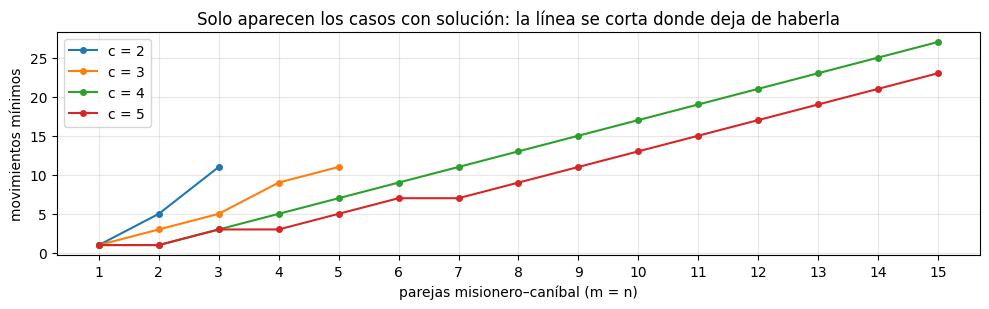

In [6]:
# ============================================================
#  AMPLIACIÓN — ¿hasta cuántas parejas aguanta cada capacidad?
# ============================================================
#  Se reutiliza el BFS propio, que es mucho más rápido que construir el grafo
#  entero cuando solo interesa saber si hay camino y de qué longitud.
capacidades = [2, 3, 4, 5]
parejas = list(range(1, 16))

tabla = {c: [bfs_misioneros(m, m, c) for m in parejas] for c in capacidades}

# --- 1. Tabla: número de movimientos, o '--' si no hay solución ---
print("m=n:  " + "".join(f"{m:>4}" for m in parejas))
for c in capacidades:
    fila = "".join(f"{'--' if v is None else v:>4}" for v in tabla[c])
    tope = [m for m, v in zip(parejas, tabla[c]) if v is None]
    limite = f"falla desde m={tope[0]}" if tope else "sin tope hasta 15"
    print(f"c={c}: " + fila + f"   <- {limite}")

# --- 2. La misma tabla, en dibujo ---
fig, ax = plt.subplots(figsize=(10, 3.2))
for c in capacidades:
    xs = [m for m, v in zip(parejas, tabla[c]) if v is not None]
    ys = [v for v in tabla[c] if v is not None]
    ax.plot(xs, ys, marker="o", ms=4, label=f"c = {c}")

ax.set_xlabel("parejas misionero–caníbal (m = n)")
ax.set_ylabel("movimientos mínimos")
ax.set_title("Solo aparecen los casos con solución: la línea se corta donde deja de haberla")
ax.set_xticks(parejas)
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

---

<div style="border-left:5px solid #555;background:#F5F5F5;padding:10px 14px;margin:10px 0;border-radius:4px;"><p><strong>🤖 REGISTRO DE USO DE IA</strong></p><ul><li><strong>Herramienta(s) utilizada(s):</strong> Claude Code (modelo Claude Opus 5).</li><li><strong>Prompt(s) utilizado(s):</strong><ol><li>«Genera la plantilla base para la actividad 02_cuestionario» + enunciado literal, y «ayuda al alumno a decidir en el chat qué opción escoger» — la IA comparó las opciones A y B, recomendó la B (se apoya en caminos mínimos, es verificable y dibujable) y rellenó Enunciado, Teoría y Datos.</li><li>«Limpia los enunciados y deja solo la opción B».</li><li>«Esta es la resolución del estudiante. Completa las celdas correspondientes, ponlas más bonitas, rellena las casillas de la IA y prepara el entregable en PDF».</li></ol></li><li><strong>Fase del ejercicio en la que se usó IA:</strong> (i) elección razonada entre las dos opciones del enunciado; (ii) material previo (Teoría y Datos); (iii) <em>maquetación</em> — paso del razonamiento a LaTeX y limpieza del código, sin alterar el modelo ni la lógica; (iv) <em>verificación</em> de los resultados; (v) ampliación. <strong>La modelización, el razonamiento y el código de las dos partes son del estudiante, sin IA.</strong></li><li><strong>Verificación de no-alucinación realizada:</strong><ul><li>[x] Resultado verificado computacionalmente con una implementación independiente — recorrido en anchura escrito desde cero, sin NetworkX ni la función del estudiante; reproduce los cinco resultados uno a uno (celda de verificación).</li><li>[x] Resultado contrastado con un caso/ejemplo conocido de la bibliografía — los $11$ movimientos del caso clásico $3+3$ y los $7$ viajes del lobo, la gallina y la lechuga son los valores documentados del problema.</li><li>[ ] Resultado contrastado analíticamente a mano.</li><li>Detalle: la afirmación fuerte de la entrega es <em>negativa</em> («$4+4$ con $c=2$ no tiene solución»), y una respuesta negativa no se puede exhibir con un ejemplo. Por eso se comprueba de dos formas que no comparten código: ausencia de camino en el grafo (<code>nx.has_path</code>) y agotamiento completo del espacio de estados por BFS propio.</li></ul></li><li><strong>Modificaciones realizadas sobre la propuesta de la IA:</strong> pendiente de revisión final del estudiante.</li><li><strong>Declaración de autoría:</strong> El razonamiento matemático y la decisión final han sido revisados y comprendidos por el/la estudiante, quien asume la responsabilidad del contenido entregado.</li></ul></div>

💬 **¿Alguna duda sobre esta actividad?** Pregunta lo que necesites, no hace falta esperar al final.